In [54]:
import torch
import numpy as np
import csv
import pandas as pd
from torch.utils.data import DataLoader, Dataset


class CovidDataset(Dataset):#dataset都有三个函数  init初始化 getitem取数据  len数据长度
    def __init__(self,file_path, mode="train"):
        self.mode = mode
        with open(file_path, "r") as f:
            ori_data = list(csv.reader(f))
            csv_data = np.array(ori_data[1:])[:, 1:].astype(float)#把csv文件的第一行去掉，第一列去掉，剩下的转成float类型

        if self.mode == "train": #逢5取1
            indices = [i for i in range(len(csv_data)) if i % 5 != 0]
            self.y = torch.tensor(csv_data[indices, -1]) #取最后一列作为标签

        elif self.mode == "val":
            indices = [i for i in range(len(csv_data)) if i % 5 == 0]
            self.y = torch.tensor(csv_data[indices, -1])

        else:
            indices = [i for i in range(len(csv_data))]
            #测试集没有标签，所以y全是0


        self.data = torch.tensor(csv_data[indices, : -1]) #取前面所有列作为数据
        self.data = (self.data - self.data.mean(dim=0, keepdim=True)) / (self.data.std(dim=0, keepdim=True) + 1e-8) #数据标准化 归一化


    def __getitem__(self, idx):
        if self.mode != "test":
            return self.data[idx].float(), self.y[idx]
        else:
            return self.data[idx].float()

    def __len__(self):
        return len(self.data)



# train_file = "covid.train.csv"
# test_file = "covid.test.csv"

# train_dataset = CovidDataset(train_file, mode="train")
# val_dataset = CovidDataset(train_file, mode="val")
# test_dataset = CovidDataset(test_file, mode="test")

# batchsize = 16
# train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True) #shuffle打乱数据,随机取数据
# val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False) #val_loader不打乱数据

# for batch_x, batch_y in train_loader:
#     print(batch_x.shape, batch_y.shape)


对于一个模型关心维度变化
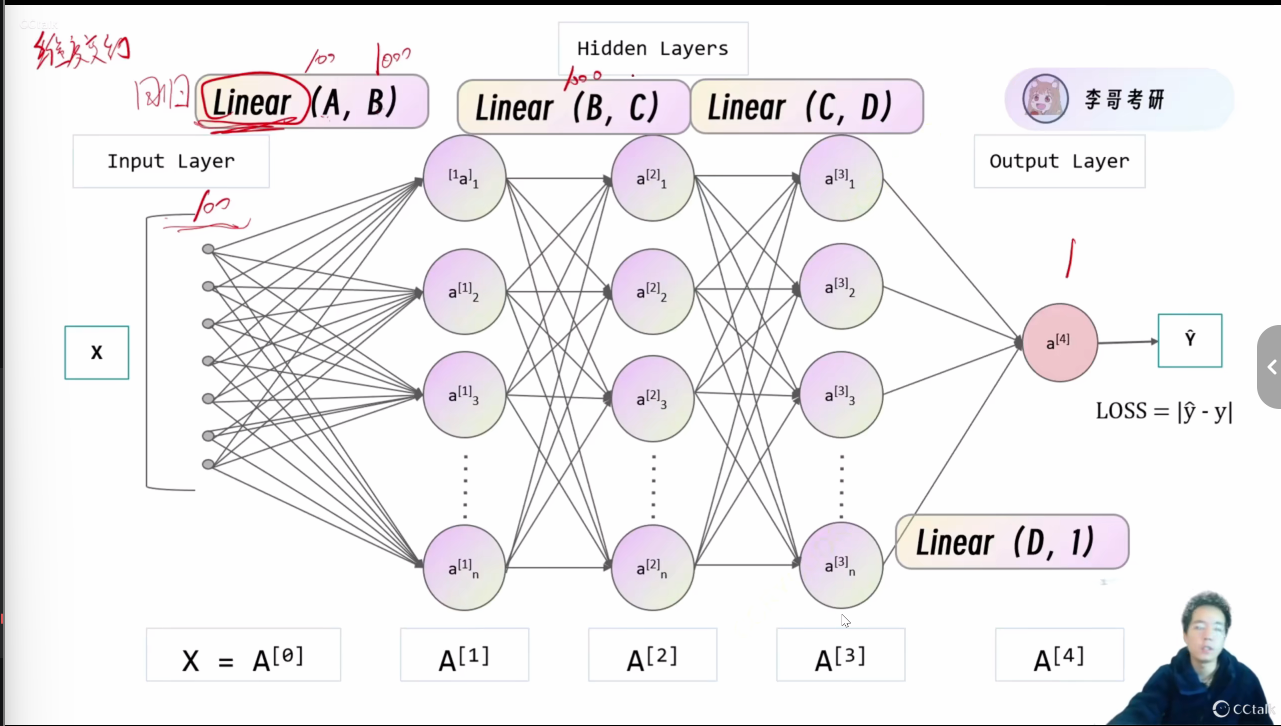

上一层linear的输出等于下一层linear的输入

(16,93) 16 是一个batch样本的数量即 1个batch 有16个样本,1个样本有93个维度

批(batch)的出现:
如果一次性算所有数据的loss:太慢  一次走多远的影响很大  

如果一个样本算一次loss：数据是分散的 有可能偏离中心点

 model部分包括两个函数 
 一个是初始化函数init 
 一个是前向传播函数forward  同样也是通过类来定义的

In [55]:
import torch.nn as nn

class CovidModel(nn.Module):
    def __init__(self, inDim):
        super(CovidModel, self).__init__()
        self.fc1 = nn.Linear(inDim, 64) #fu = fully connected 全连接层
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self,x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        if len(x.size()) > 1:
            return x.squeeze(1) #把第二维去掉

        return x



 
# model = CovidModel(inDim = 93)

# predy = model(batch_x)

# device = "cuda" if torch.cuda.is_available() else "cpu" #如果有GPU就用GPU，否则用CPU
# print(device)





如果CUDA可以用就用显卡 如果 CUDA不可以用就用CPU

In [56]:
#训练
import time
import matplotlib as plt
def train_val(model, train_loader, val_loader,device, epochs,optimizer,loss,save_path):
    model = model.to(device)

    plt_train_loss = [] #记录每个epoch的训练损失
    plt_val_loss = [] #记录每个epoch的验证损失

    min_val_loss = float("inf")

    for epoch in range(epochs): # 开始训练的号角
        train_loss = 0.0
        val_loss = 0.0
        start_time = time.time()

        model.train() #训练模型模式
        for batch_x, batch_y in train_loader:
            x, target = batch_x.to(device), batch_y.to(device)
            pred = model(x) #模型预测
            train_batch_loss = loss(pred, target) #计算损失
            train_batch_loss.backward() #反向传播
            optimizer.step() #更新参数
            optimizer.zero_grad() #清空梯度
            train_loss = train_batch_loss.cpu.item() #把损失从GPU上拿下来，转成python的float类型

        plt_train_loss.append(train_loss/len(train_loader)) #记录训练损失

#验证,注意验证集不更新模型
        model.eval()
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                x, target = batch_x.to(device), batch_y.to(device)
                pred = model(x)
                val_batch_loss = loss(pred, target)
                val_loss += val_batch_loss.cpu().item()

        plt_val_loss.append(val_loss / len(val_loader)) #记录验证损失
        
        #保存模型 
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(model.state_dict(), save_path) #保存模型参数

        print("[%0.3d/%0.3d] %2.2f sec(s) Trainloss: %.6f |Valloss: %.6f" % \
              (epoch, epochs, time.time() - start_time,plt_train_loss[-1],plt_val_loss[-1]))

    plt.plot(plt_train_loss)
    plt.plt(plt_val_loss)
    plt.title("loss图")
    plt.legend(["train","val"])
    plt.show()

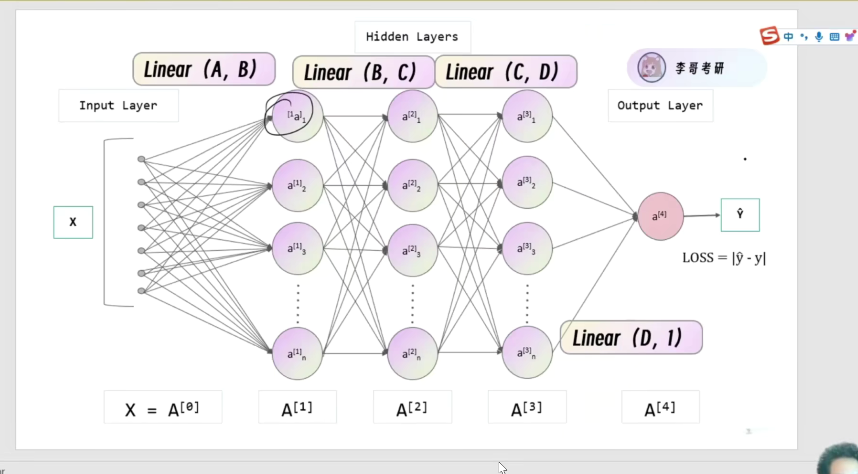
Q:为什么写model.train?
A:对于某些模型，在训练的时候会随机丢弃一半的节点，在测试的时候使用全部的节点

In [57]:
train_file = "covid.train.csv"
test_file = "covid.test.csv"

train_dataset = CovidDataset(train_file, mode="train")
val_dataset = CovidDataset(train_file, mode="val")
test_dataset = CovidDataset(test_file, mode="test")

batchsize = 16
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True) #shuffle打乱数据,随机取数据
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False) #val_loader不打乱数据


model = CovidModel(inDim = 93)

predy = model(batch_x)

device = "cuda" if torch.cuda.is_available() else "cpu" #如果有GPU就用GPU，否则用CPU


config = {
    "lr":0.01,
    "epochs":20,
    "monmentum":0.9,
    "save_path":"model_save/best_model.pth"
}

model = CovidModel(inDim = 93).to(device)
loss = nn.MSELoss() #均方误差损失函数

from torch import optim #优化器 使用官方的优化器
optimizer = optim.SGD(model.parameters(),lr = config["lr"],momentum = config["monmentum"]) #SGD随机梯度下降优化器，model.parameters()模型的参数，lr学习率，momentum动量

